# ***Ⅲ. 이미지 데이터 처리***
## ***04. 이미지 데이터의 분류 응용 - 2***
- MNIST 데이터셋의 유래인 우편번호를 인식해봅니다
- 단순히 숫자가 아니라 규격봉투에 적힌 우편번호 입니다

In [3]:
# imshow함수 준비
import cv2
import numpy as np
from matplotlib import pyplot as plt

def cv2_imshow(img, title='Image', figsize=(5,5), axis='on'):
    # BGR -> RGB 변환
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis(axis)
    plt.show()

## ***랜덤 시드 초기화***
- 랜덤 패턴의 시작값을 동일하게 하면 동일한 랜덤 패턴을 얻을 수 있습니다

In [4]:
np.random.seed(42)

### ***MNIST모델 만들기***
- 일단 지난시간에 만들었던 MNIST 모델을 다시 만듭니다
- 밝기 변화를 점진적으로 단계화하여 데이터를 개선합니다

In [5]:
contrast_values = np.linspace(0.3, 1.7, 10)
brightness_values = np.linspace(-40, 40, 5)

print(contrast_values)
print(brightness_values)

[0.3        0.45555556 0.61111111 0.76666667 0.92222222 1.07777778
 1.23333333 1.38888889 1.54444444 1.7       ]
[-40. -20.   0.  20.  40.]


In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

num_groups = len(contrast_values) * len(brightness_values)

chunk_size = len(x_train) // num_groups

x_train_aug = x_train.copy()

idx = 0

for contrast in contrast_values:
    for brightness in brightness_values:

        start = idx * chunk_size

        # 마지막 chunk 처리
        if idx == num_groups - 1:
            end = len(x_train)
        else:
            end = (idx + 1) * chunk_size

        x_train_aug[start:end] = np.clip(x_train_aug[start:end].astype(np.float32) * contrast + brightness, 0, 255)

        idx += 1

x_train = np.concatenate([x_train, x_train_aug, 255 - x_train, 255 - x_train_aug], axis=0)
y_train = np.concatenate([y_train, y_train, y_train, y_train], axis=0)

# 테스트셋은 원본 유지
x_test = x_test.astype(np.float32)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

tf.random.set_seed(42)
# FCN 모델 (Fully Connected Network only)
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # CNN 블록
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # CNN 블록
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # CNN 블록
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),

    # 최종 분류
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 학습
model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.1)

# 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/3
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 140s 41ms/step - accuracy: 0.9650 - loss: 0.1156 - val_accuracy: 0.9884 - val_loss: 0.0363
Epoch 2/3
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 133s 39ms/step - accuracy: 0.9888 - loss: 0.0379 - val_accuracy: 0.9942 - val_loss: 0.0176
Epoch 3/3
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 122s 36ms/step - accuracy: 0.9922 - loss: 0.0257 - val_accuracy: 0.9954 - val_loss: 0.0149
Test Accuracy: 0.9922


## ***편지봉투에 적힌 숫자 읽기***
- MNIST를 학습한 모델을 이용해 편지봉투에 적힌 숫자를 읽습니다
- 당연히 실패합니다
- 이미지의 분류에는 기본적으로 이미지 내에 존재하는 모든 픽셀의 값이 고려됩니다

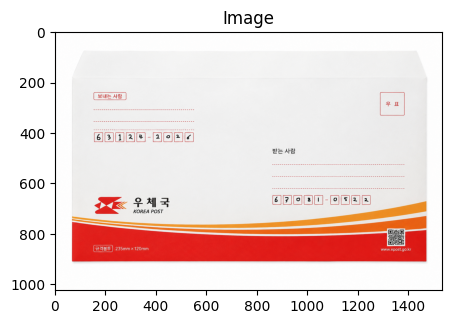

In [44]:
import cv2

img = cv2.imread('post_envelop_written.png')
cv2_imshow(img)

## ***MNIST모델이 실제로 본 이미지***
- 28x28 크기의 흑백이미지 입니다
- 숫자 성분은 이미 알아볼 수 없을만큼 소멸된 상태 입니다

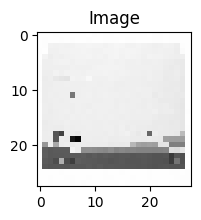

In [45]:
img = cv2.imread('post_envelop_written.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28)) 
cv2_imshow(img, figsize=(2,2))

### ***인식결과***
- 아래 인식결과는 위에 보여지는 이미지를 인식한 결과입니다
- 이미 숫자성분은 소멸하였고 위에 보여지는 내용을 바탕으로 분류된 결과이므로 의미가 없습니다

In [47]:
import cv2
import numpy as np

# 이미지를 흑백으로 읽기
img = cv2.imread("post_envelop_written.png", cv2.IMREAD_GRAYSCALE)

# 2. 전처리 (28x28, 정규화)
img = cv2.resize(img, (28, 28))        # 크기 맞추기

# 3. 정규화및 모델 입력 형태 맞추기 (batch, 28, 28, 1)
img = img.reshape(-1, 28, 28, 1).astype('float32') / 255.0   # 0~1 정규화

# 4. 예측
pred = model.predict(img)
import numpy as np

np.set_printoptions(suppress=True, precision=6)
print("각 숫자별 확률:")
for i, p in enumerate(pred[0]):
    print(f"{i}: {p:.6f}")

digit = np.argmax(pred[0])
print("예측된 숫자:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
각 숫자별 확률:
0: 0.000002
1: 0.995640
2: 0.002851
3: 0.001165
4: 0.000001
5: 0.000337
6: 0.000002
7: 0.000000
8: 0.000000
9: 0.000003
예측된 숫자: 1


## ***우편번호 영역별로 인식영역 설정하기***
- 이번에는 우편번호를 적는 각 네모칸을 인식영역으로 설정해보겠습니다
- 아래보여지는 이미지는 실제 MNIST 모델이 인식할 내용입니다

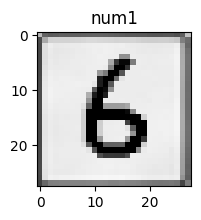

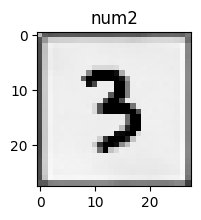

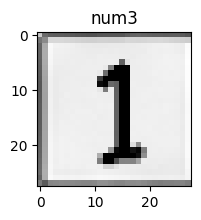

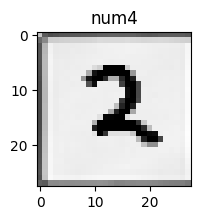

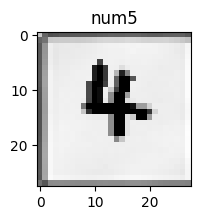

In [54]:
img = cv2.imread('post_envelop_written.png', cv2.IMREAD_GRAYSCALE)
num1 = img[401:438, 155:190]
num1 = cv2.resize(num1, (28, 28))
cv2_imshow(num1, title='num1', figsize=(2,2))

num2 = img[401:438, 197:231]
num2 = cv2.resize(num2, (28, 28))
cv2_imshow(num2, title='num2', figsize=(2,2))

num3 = img[401:438, 239:272]
num3 = cv2.resize(num3, (28, 28))
cv2_imshow(num3, title='num3', figsize=(2,2))

num4 = img[401:438, 281:314]
num4 = cv2.resize(num4, (28, 28))
cv2_imshow(num4, title='num4', figsize=(2,2))

num5 = img[401:438, 323:356]
num5 = cv2.resize(num5, (28, 28))
cv2_imshow(num5, title='num5', figsize=(2,2))


### ***인식결과***
- 모두 인식에 성공하였습니다
- 이제 해당 위치에 다른 숫자를 써서 테스트 해보겠습니다
- `받는사람` 영역에 있는 우편번호로도 테스트 해보겠습니다

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


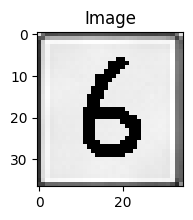

각 숫자별 확률:
0: 0.000000
1: 0.000000
2: 0.000000
3: 0.000000
4: 0.000000
5: 0.000001
6: 0.999999
7: 0.000000
8: 0.000000
9: 0.000000
예측된 숫자: 6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


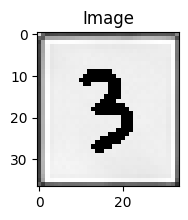

각 숫자별 확률:
0: 0.000000
1: 0.000000
2: 0.000000
3: 1.000000
4: 0.000000
5: 0.000000
6: 0.000000
7: 0.000000
8: 0.000000
9: 0.000000
예측된 숫자: 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


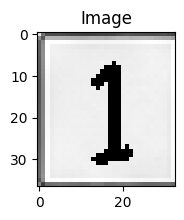

각 숫자별 확률:
0: 0.000000
1: 0.999233
2: 0.000014
3: 0.000007
4: 0.000000
5: 0.000004
6: 0.000000
7: 0.000610
8: 0.000000
9: 0.000131
예측된 숫자: 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


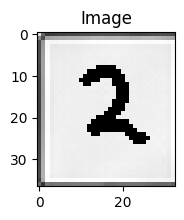

각 숫자별 확률:
0: 0.000000
1: 0.000000
2: 0.999999
3: 0.000001
4: 0.000000
5: 0.000000
6: 0.000000
7: 0.000000
8: 0.000000
9: 0.000000
예측된 숫자: 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


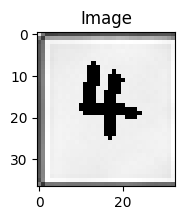

각 숫자별 확률:
0: 0.000000
1: 0.000008
2: 0.000002
3: 0.000000
4: 0.999947
5: 0.000000
6: 0.000007
7: 0.000036
8: 0.000000
9: 0.000000
예측된 숫자: 4



In [52]:
import cv2
import numpy as np


for num in [num1, num2, num3, num4, num5]:
    # 이미지를 흑백으로 읽기
    num = cv2.cvtColor(num, cv2.COLOR_BGR2GRAY)

    # 2. 전처리 (28x28, 정규화)
    num_resize = cv2.resize(num, (28, 28))        # 크기 맞추기

    # 3. 정규화및 모델 입력 형태 맞추기 (batch, 28, 28, 1)
    num_input = num_resize.reshape(-1, 28, 28, 1).astype('float32') / 255.0   # 0~1 정규화

    # 4. 예측
    pred = model.predict(num_input)
    import numpy as np

    np.set_printoptions(suppress=True, precision=6)

    cv2_imshow(num, figsize=(2,2))
    print("각 숫자별 확률:")
    for i, p in enumerate(pred[0]):
        print(f"{i}: {p:.6f}")

    digit = np.argmax(pred[0])
    print("예측된 숫자:", digit)
    print("==================================================")
    print()

## ***객체 인식 모델***
- 만약 우리가 우편봉투에서 우편번호의 위치를 인식할 수 있다면 어떨까요?
- 객체 인식 모델은 객체의 위치를 인식하고 어떤 객체인지 분류합니다
- 이 때 어떤 객체인지는 어떻게 분류할지 우리는 압니다
- 그러면 위치는 어떻게 인식시킬 수 있을까요?
- 위치도 0 ~ 1 사이의 숫자로 변환시키면 됩니다
- 2차시에서는 위치의 라벨링 까지만 확인하고 3차시에서 객체인식 모델을 다룹니다

In [ ]:
import urllib.request
import zipfile
import os

url = "https://ultralytics.com/assets/coco128.zip"
save_path = "coco128.zip"

# url에 있는 파일을 다운로드
urllib.request.urlretrieve(url, save_path)

# 압축 해제
with zipfile.ZipFile(save_path, 'r') as zip_ref:
    zip_ref.extractall()

### ***객체의 이름:숫자 변환 체계 확인하기***
- 아래 링크를 눌러서 위 데이터의 정의를 기록한 파일을 확인합니다
  - https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco128.yaml
- 아래 부분을 찾아서 확인해봅니다
```yaml
# Classes
names:
```

### ***다운로드 받은 데이터 시각화하기***
- 위치 라벨링 체계는 아래와 같습니다
  - x_center: 객체를 둘러싸는 사각형 박스의 중심점에 대한 x 좌표를 이미지의 너비로 나눈 값
  - y_center: 객체를 둘러싸는 사각형 박스의 중심점에 대한 y 좌표를 이미지의 높이로 나눈 값
  - width: 객체를 둘러싸는 사각형 박스의 너비를 이미지의 너비로 나눈 값
  - height: 객체를 둘러싸는 사각형 박스의 높이를 이미지의 높비로 나눈 값
- 왜 이러한 체계로 기록을 했을까요?
  - 정규화 때문입니다
  - 위의 각 문장을 다시 읽어보면 공통적으로 "이미지의 너비로 나눈 값", "이미지의 높이로 나눈 값" 을 확인할 수 있습니다
  - 색상 정보를 255로 나누어서 정규화 했던 것을 다시 생각해봅시다
  - 정규화를 함으로써 색상 정보 체계와 무관하게 0 ~ 1 사이로 표현됩니다
  - 마찬가지로 객체의 위치, 크기도 정규화를 함으로써 이미지의 크기와 무관하게 0 ~ 1사이로 표현되는 것입니다

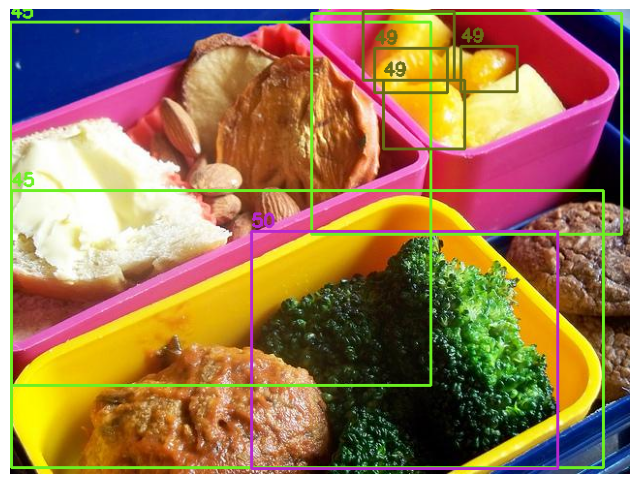

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# 경로 설정
img_dir = "coco128/images/train2017"
label_dir = "coco128/labels/train2017"

# 여기에 있는 이미지파일 이름을 바꿔가면서 테스트 해봅니다
img_name = "000000000009.jpg" 

# images 디렉토리 내의 해당 이미지 경로
img_path = os.path.join(img_dir, img_name)

# labels 디렉토리 내의 해당 이미지 경로
label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

# 이미지 불러오기
img = cv2.imread(img_path)
h, w, c = img.shape

# 박스 색상 80가지를 랜덤으로 정의
random.seed(20)
colors=[(random.randint(0,255),random.randint(0,255),random.randint(0,255)) for _ in range(80)]

# 라벨 읽기
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x_center, y_center, box_width, box_height = map(float, line.strip().split())
            cls = int(cls)

            # 원래 좌표로 변환
            x_center, y_center, box_width, box_height = x_center * w, y_center * h, box_width * w, box_height * h
            left = int(x_center - box_width / 2)
            top = int(y_center - box_height / 2)
            right = int(x_center + box_width / 2)
            bottom = int(y_center + box_height / 2)

            # 이미지 위에 초록색 박스 그리기
            # 왼쪽 위, 오른쪽 아래 꼭지점 정보를 주면 박스를 그릴 수 있습니다
            # 박스의 색은 (0, 255, 0)으로 (B, G, R) 체계에 의해 초록색 입니다
            # 박스의 선굵기는 2 입니다
            cv2.rectangle(img, (left, top), (right, bottom), colors[cls], 2)
            cv2.putText(img, str(cls), (left, top - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[cls], 2)

# 원본 이미지 위에 박스가 그려진 이미지를 시각화
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()


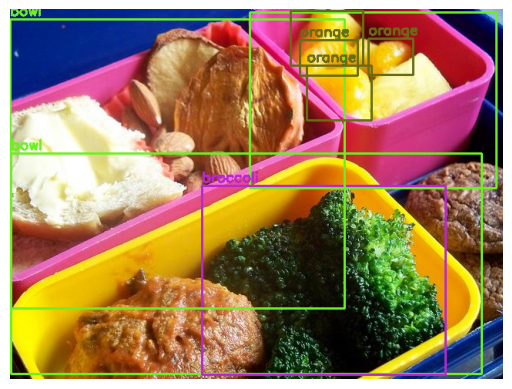

In [ ]:
import cv2
import random
import matplotlib.pyplot as plt

# COCO 클래스 이름 dict
names = {
    0: "person", 1: "bicycle", 2: "car", 3: "motorcycle", 4: "airplane",
    5: "bus", 6: "train", 7: "truck", 8: "boat", 9: "traffic light",
    10: "fire hydrant", 11: "stop sign", 12: "parking meter", 13: "bench",
    14: "bird", 15: "cat", 16: "dog", 17: "horse", 18: "sheep", 19: "cow",
    20: "elephant", 21: "bear", 22: "zebra", 23: "giraffe", 24: "backpack",
    25: "umbrella", 26: "handbag", 27: "tie", 28: "suitcase", 29: "frisbee",
    30: "skis", 31: "snowboard", 32: "sports ball", 33: "kite", 34: "baseball bat",
    35: "baseball glove", 36: "skateboard", 37: "surfboard", 38: "tennis racket",
    39: "bottle", 40: "wine glass", 41: "cup", 42: "fork", 43: "knife",
    44: "spoon", 45: "bowl", 46: "banana", 47: "apple", 48: "sandwich",
    49: "orange", 50: "broccoli", 51: "carrot", 52: "hot dog", 53: "pizza",
    54: "donut", 55: "cake", 56: "chair", 57: "couch", 58: "potted plant",
    59: "bed", 60: "dining table", 61: "toilet", 62: "tv", 63: "laptop",
    64: "mouse", 65: "remote", 66: "keyboard", 67: "cell phone", 68: "microwave",
    69: "oven", 70: "toaster", 71: "sink", 72: "refrigerator", 73: "book",
    74: "clock", 75: "vase", 76: "scissors", 77: "teddy bear", 78: "hair drier",
    79: "toothbrush"
}

# 예시 이미지와 annotation 불러오기
img = cv2.imread("coco128/images/train2017/000000000009.jpg")
h, w, c = img.shape

# 박스 색상 80가지를 랜덤으로 정의
random.seed(20)
colors=[(random.randint(0,255),random.randint(0,255),random.randint(0,255)) for _ in range(80)]

with open("coco128/labels/train2017/000000000009.txt") as f:
    for line in f:
        cls, x, y, box_width, box_height = map(float, line.split())
        cls = int(cls)
        # YOLO 포맷 (정규화 좌표 → 픽셀 좌표)
        left = int((x - box_width/2) * w)
        top = int((y - box_height/2) * h)
        right = int((x + box_width/2) * w)
        bottom = int((y + box_height/2) * h)

        cv2.rectangle(img, (left, top), (right, bottom), colors[cls], 2)
        cv2.putText(img, names[cls], (left, top-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[cls], 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## ***이미지 데이터 처리를 이용한 인식률 높이기***
- 이미지 자르기, 회전하기를 이용하여 인식률을 높여봅니다
- 왜 이미지를 자르고 회전하면 인식률이 올라가는지 그 이유를 알아봅니다

### ***YOLO 모델의 입력 이미지 크기***
- 우리는 MNIST 모델에 우리의 손글씨를 입력으로 사용할 때 28x28으로 리사이징 했습니다
- YOLO에서는 모델에 따라 대개 416x416 또는 608x608을 사용합니다
  - 대개라는 말은 우리가 이를 수정할 수 있음을 의미합니다
  - 그러나 우리는 기존에 학습된 모델을 사용하기 때문에 그 모델의 학습과정에서 사용한 입력 크기를 사용해야 합니다
  - 그 입력 크기가 416x416, 608x608 또는 640x640 입니다

### ***YOLO11n모델의 입력 크기 확인하기***
- https://docs.ultralytics.com/ko/models/yolo11#performance-metrics 에서 확인합니다
- 640x640 임을 확인할 수 있습니다

### ***인식 대상 이미지 크기 확인하기***
- shape은 각 차원 성분의 크기를 의미합니다
- [행 렬] 이기 때문에 행 성분이 먼저 나오고 이어서 열 성분이 나옵니다
- 마지막으로 색상 성분입니다
- 3차시에 인식했던 이미지는 가로 640, 세로 406의 컬러 이미지 입니다


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


filename = "coco128/images/train2017/000000000488.jpg"

img = cv2.imread(filename)
img.shape



### ***640x406 이미지를 640x640으로 리사이징할 때 발생하는 일***
- 세로 성분 406픽셀이 640으로 늘어납니다
- 이 때 640 - 406 = 234픽셀의 정보는 어떻게 만들어질까요?
  - 보간법으로 만들어집니다
  - 예를 들면 두 픽셀 사이의 평균값으로 채우는 것입니다
  - 이미지를 크게 늘리면 계단현상이라는 것이 생기는 이유입니다
  - 즉, 불완전한 정보로 채워진다는 것을 의미합니다
  - 이미지를 과하게 작게 자르면 이 보간법에 의해 이미지가 왜곡되는 일이 발생함에 유의합시다

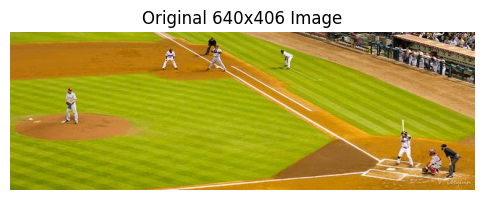

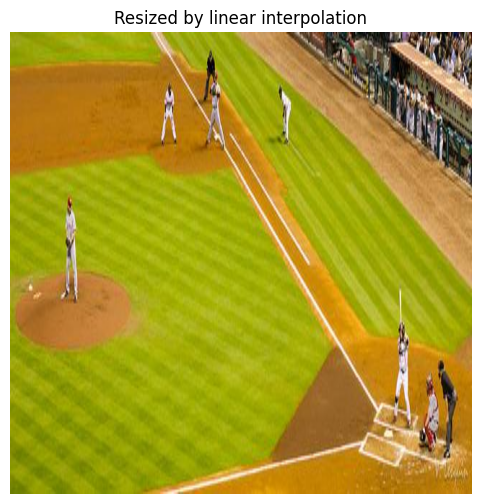

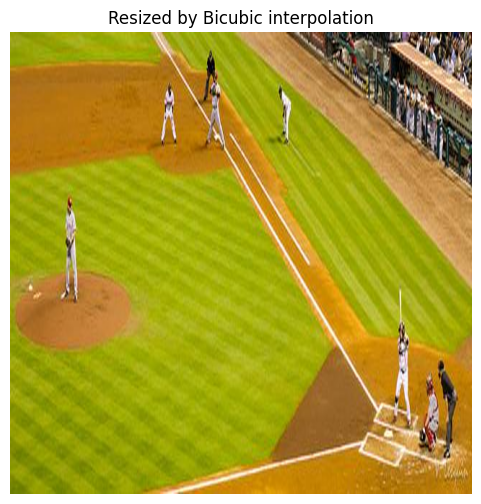

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

filename = "coco128/images/train2017/000000000357.jpg"

img = cv2.imread(filename)
h, w, c = img.shape

img_org = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.title("Original 640x406 Image")
plt.imshow(img_org)
plt.axis("off")
plt.show()

# 선형 보간법에 의한 리사이징
img_resized = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LINEAR)

img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.title("Resized by linear interpolation")
plt.imshow(img_resized)
plt.axis("off")
plt.show()

# Bicubic 보간법에 의한 리사이징
img_resized_cubic = cv2.resize(img, (640, 640), interpolation=cv2.INTER_CUBIC)

img_resized_cubic = cv2.cvtColor(img_resized_cubic, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.title("Resized by Bicubic interpolation")
plt.imshow(img_resized_cubic)
plt.axis("off")
plt.show()


### ***이미지 자르기를 이용해 인식되지 않은 사람 인식시켜보기***
- 이미짐는 행렬이기 때문에 행렬을 부분적으로 취하면 이미지를 자르는 것이 됩니다
- 아래 코드에서 left, top, right, bottom를 변경하면서 이미지를 잘라봅시다
- 그러면 행 성분은 top부터 bottom까지, 열 성분은 left부터 right까지 부분행렬을 가져옵니다
- 인식되지 않은 사람이 크게 나오도록 이미지를 잘라봅시다

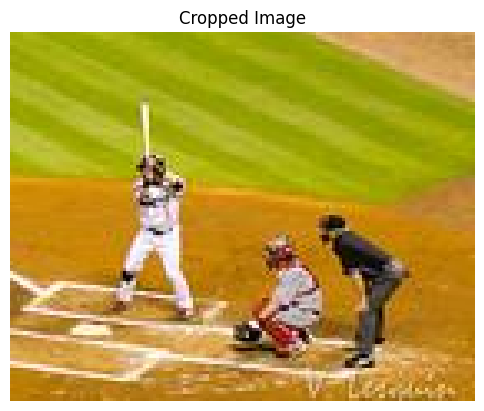

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 이 부분을 변경하면서 이미지를 잘라봅니다
left, top, right, bottom = 500, 100, 640, 211

filename = "coco128/images/train2017/000000000357.jpg"
img = cv2.imread(filename)
h, w, c = img.shape

# 행 성분은 top부터 bottom까지, 열 성분은 left부터 right까지 부분행렬을 가져옵니다
# 이미지를 행렬이기 때문에 이것이 이미지를 자르는 것이 됩니다
cropped_img = img[top:bottom, left:right]

cropped_img = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(cropped_img)
plt.title("Cropped Image")
plt.axis("off")
plt.show()


### ***자른 이미지로 인식 시키기***
- 원본 이미지에서는 인식하지 못했던 야구방망이 이미지가 어떻게 인식 되는지 확인해봅시다


0: 512x640 3 persons, 1 baseball bat, 447.4ms
Speed: 5.8ms preprocess, 447.4ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)


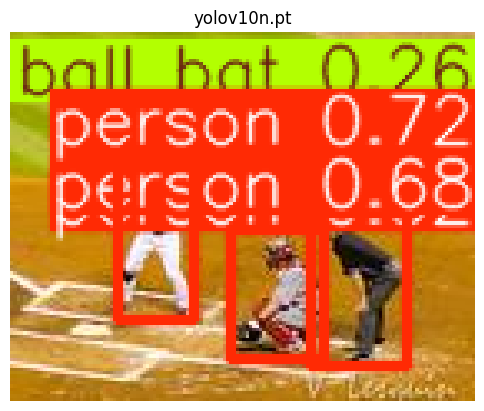

In [ ]:
weight = "yolo11n.pt"

model = YOLO("yolo11n.pt")     # 모델 불러오기
results = model(cropped_img)    # 추론

# 결과 시각화
res_plotted = results[0].plot()  # 결과 그리기
plt.figure(figsize=(6, 6))
plt.imshow(res_plotted)
plt.axis("off")
plt.title(weight)
plt.show()

### ***결과 생각해보기***
- 이미지를 부분적으로 자르면서 인식되지 않았던 작은 객체의 크기는 커졌습니다
- 이로 인해 일부 인식이 되기도 했지만 잘못된 객체로 인식되기도 했습니다
- 보간법에 의해 만들어진 정보가 노이즈로 작용한 것입니다

### ***이미지 회전시키기***
- 이제부터 수학시간에 배운 회전행렬을 활용할 것입니다

\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}

- 아래에 테디베어가 dog로 인식된 것을 이미지 회전을 통해 바로 잡아봅니다



0: 640x640 2 dogs, 682.5ms
Speed: 8.7ms preprocess, 682.5ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)


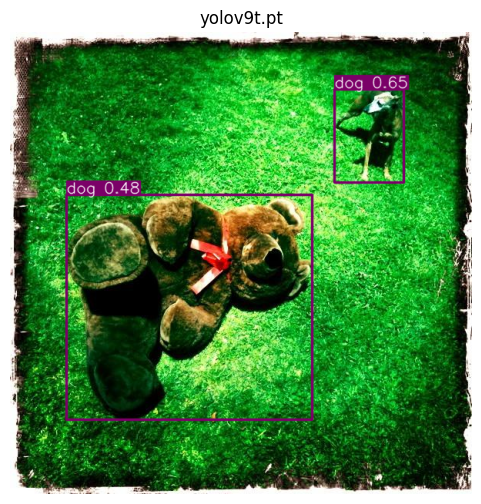

In [ ]:
filename = "coco128/images/train2017/000000000309.jpg"
img = cv2.imread(filename)
h, w, c = img.shape

weight = "yolo11n.pt"

model = YOLO(weight)        # 모델 불러오기
results = model(img)    # 인식하기

# 결과 시각화
res_plotted = results[0].plot()
res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(res_plotted)
plt.axis("off")
plt.title(weight)
plt.show()

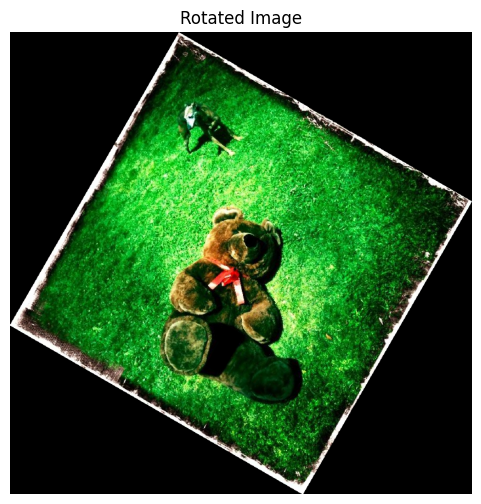

In [ ]:
import numpy as np

# 각도를 다양하게 변화시켜봅니다

angle_deg = -60

filename = "coco128/images/train2017/000000000309.jpg"
img = cv2.imread(filename)
h, w, c = img.shape

angle_rad = np.deg2rad(angle_deg)


# 회전행렬
R = np.array([
    [np.cos(angle_rad), -np.sin(angle_rad)],
    [np.sin(angle_rad), np.cos(angle_rad)]
])

cos_theta = R[0][0]
sin_theta = R[1][0]

# Calculate new image dimensions
new_w = int(abs(w * cos_theta) + abs(h * sin_theta))
new_h = int(abs(h * cos_theta) + abs(w * sin_theta))

# Center offsets
ox, oy = w / 2, h / 2
nx, ny = new_w / 2, new_h / 2

# Prepare empty output image
rotated_img = np.zeros((new_h, new_w, c), dtype=img.dtype)

# Iterate over each pixel in the output
for y in range(new_h):
    for x in range(new_w):
        # Transform back to original image coordinates
        tx = (x - nx) * cos_theta + (y - ny) * sin_theta + ox
        ty = -(x - nx) * sin_theta + (y - ny) * cos_theta + oy

        tx_int = int(round(tx))
        ty_int = int(round(ty))

        # If inside original image, copy pixel
        if 0 <= tx_int < w and 0 <= ty_int < h:
            rotated_img[y, x] = img[ty_int, tx_int]

rotated_img = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(rotated_img)
plt.title("Rotated Image")
plt.axis("off")
plt.show()


### ***회전시킨 이미지의 인식***
- 60도 회전시킨 후 다시 인식을 해보면 테디베어로 정상 인식되는 것을 확인할 수 있습니다


0: 640x640 1 dog, 1 teddy bear, 868.2ms
Speed: 9.9ms preprocess, 868.2ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)


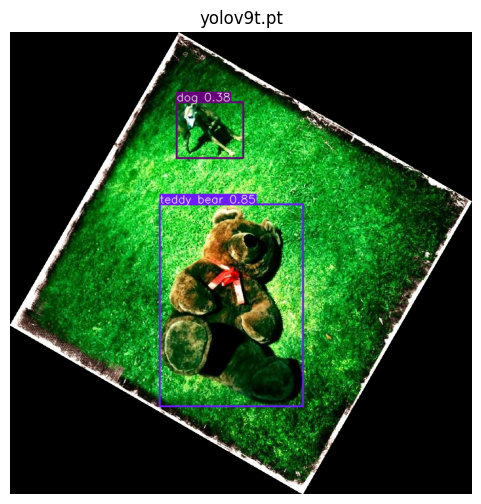

In [ ]:
model = YOLO(weight)        # 모델 불러오기
results = model(rotated_img)    # 인식하기

# 결과 시각화
res_plotted = results[0].plot()
plt.figure(figsize=(6, 6))
plt.imshow(res_plotted)
plt.axis("off")
plt.title(weight)
plt.show()

### ***이미지를 회전시키고 자르기***
- 아래의 예제에서는 원본 이미지에서 인식하지 못하는 와인잔을 인식시켜보겠습니다
- 원본 이미지에서는 사람은 잘 인식하지만 와인잔은 5개의 YOLO모델이 전혀 인식하지 못합니다


0: 448x640 1 person, 407.9ms
Speed: 3.5ms preprocess, 407.9ms inference, 3.2ms postprocess per image at shape (1, 3, 448, 640)


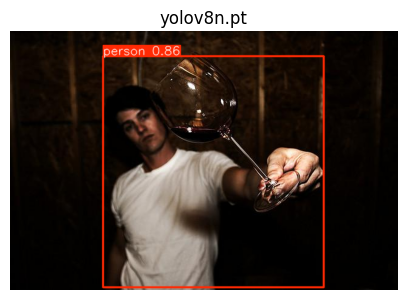


0: 448x640 1 person, 537.8ms
Speed: 3.7ms preprocess, 537.8ms inference, 3.3ms postprocess per image at shape (1, 3, 448, 640)


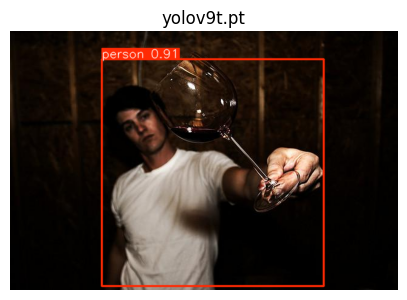


0: 448x640 1 person, 407.3ms
Speed: 4.0ms preprocess, 407.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


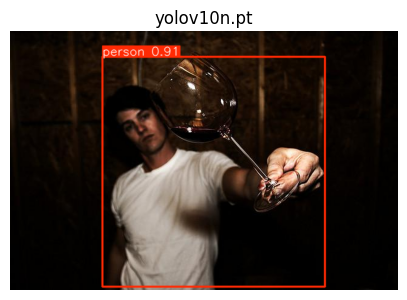


0: 448x640 1 person, 1 baseball bat, 437.6ms
Speed: 3.0ms preprocess, 437.6ms inference, 3.1ms postprocess per image at shape (1, 3, 448, 640)


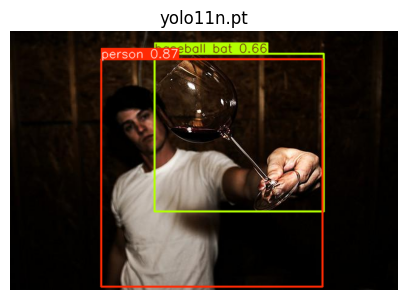


0: 448x640 1 person, 1 tennis racket, 492.7ms
Speed: 5.5ms preprocess, 492.7ms inference, 4.5ms postprocess per image at shape (1, 3, 448, 640)


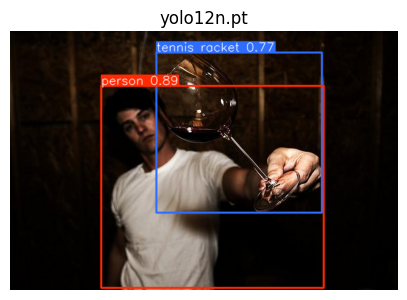

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 이번 시간에 사용할 YOLO 모델들 정의
models = [
    "yolov8n.pt",
    "yolov9t.pt",
    "yolov10n.pt",
    "yolo11n.pt",
    "yolo12n.pt"
]

############################################
# coco128 데이터 셋에 있는 와인잔 이미지 입니다 #
############################################
filename = "coco128/images/train2017/000000000326.jpg"

# 이미지 불러오기
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 각 모델별 추론 실행
for weight in models:
    model = YOLO(weight)        # 모델 불러오기
    results = model(img_rgb)    # 추론
    
    # 결과 시각화
    res_plotted = results[0].plot()  # 결과 그리기
    plt.figure(figsize=(5, 5))
    plt.imshow(res_plotted)
    plt.axis("off")
    plt.title(weight)
    plt.show()


### 이미지 변환 후 인식 결과
- 우선 이미지는 와인잔을 중심으로 정사각형이 되게 자릅니다
- 이미지 회전을 통해 기울어진 와인잔을 세웁니다

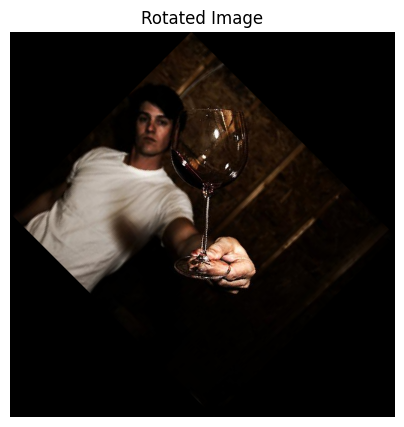

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이 부분을 변경하면서 이미지를 자르고 회전시켜봅니다
left, top, right, bottom = 150, 0, 630, 480
angle_deg = 45

filename = "coco128/images/train2017/000000000326.jpg"
img = cv2.imread(filename)

# 행 성분은 top부터 bottom까지, 열 성분은 left부터 right까지 부분행렬을 가져옵니다
# 이미지를 행렬이기 때문에 이것이 이미지를 자르는 것이 됩니다
cropped_img = img[top:bottom, left:right]

h, w, c = cropped_img.shape

angle_rad = np.deg2rad(angle_deg)

# 회전행렬
R = np.array([
    [np.cos(angle_rad), -np.sin(angle_rad)],
    [np.sin(angle_rad), np.cos(angle_rad)]
])

cos_theta = R[0][0]
sin_theta = R[1][0]

# 회전된 이미지의 새로운 너비와 높이를 구합니다
new_w = int(abs(w * cos_theta) + abs(h * sin_theta))
new_h = int(abs(h * cos_theta) + abs(w * sin_theta))

# 원본 이미지의 중심점
ox, oy = w / 2, h / 2

# 회전된 이미지의 중심점
nx, ny = new_w / 2, new_h / 2

# Prepare empty output image
rotated_cropped_img = np.zeros((new_h, new_w, c), dtype=cropped_img.dtype)

# 이미지의 각 픽셀별로 회전행렬을 적용합니다
for y in range(new_h):
    for x in range(new_w):
        tx = (x - nx) * cos_theta + (y - ny) * sin_theta + ox
        ty = -(x - nx) * sin_theta + (y - ny) * cos_theta + oy

        tx_int = int(round(tx))
        ty_int = int(round(ty))

        if 0 <= tx_int < w and 0 <= ty_int < h:
            rotated_cropped_img[y, x] = cropped_img[ty_int, tx_int]

rotated_cropped_img = cv2.cvtColor(rotated_cropped_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(rotated_cropped_img)
plt.title("Rotated Image")
plt.axis("off")
plt.show()



0: 640x640 1 person, 1 wine glass, 662.0ms
Speed: 9.3ms preprocess, 662.0ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 640)


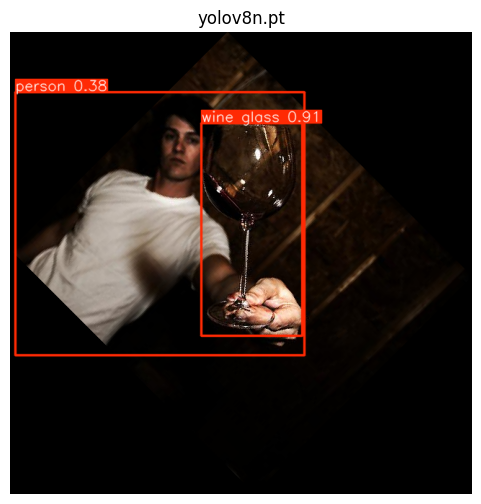


0: 640x640 1 person, 1 wine glass, 691.3ms
Speed: 11.3ms preprocess, 691.3ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)


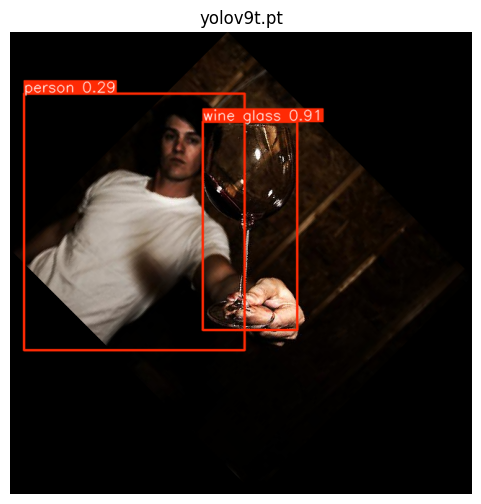


0: 640x640 2 persons, 1 wine glass, 555.2ms
Speed: 9.3ms preprocess, 555.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


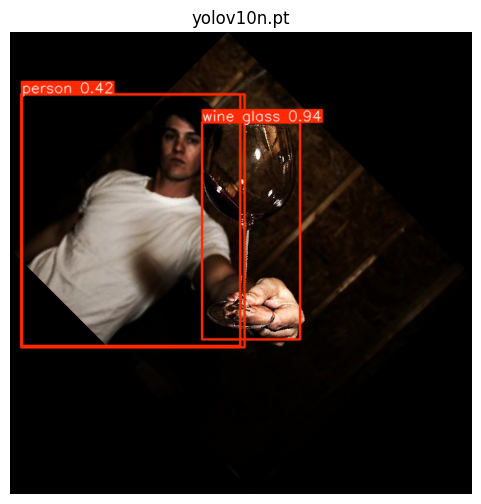


0: 640x640 1 person, 1 wine glass, 573.8ms
Speed: 8.4ms preprocess, 573.8ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)


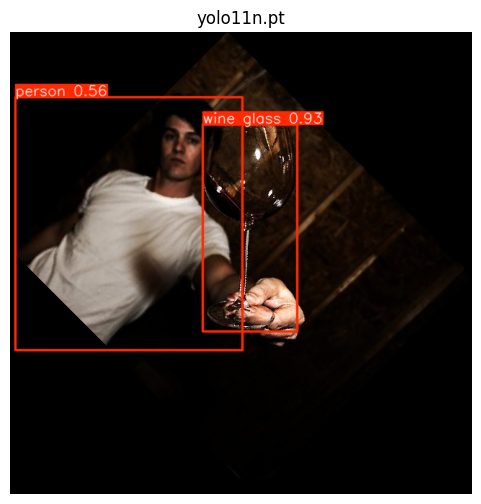


0: 640x640 1 person, 1 wine glass, 640.7ms
Speed: 8.9ms preprocess, 640.7ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)


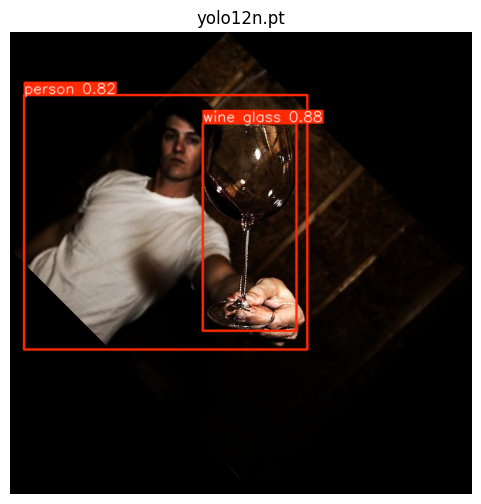

In [ ]:
# 이번 시간에 사용할 YOLO 모델들 정의
models = [
    "yolov8n.pt",
    "yolov9t.pt",
    "yolov10n.pt",
    "yolo11n.pt",
    "yolo12n.pt"
]

# 각 모델별 추론 실행
for weight in models:
    model = YOLO(weight)        # 모델 불러오기
    results = model(rotated_cropped_img)    # 인식하기
    
    # 결과 시각화
    res_plotted = results[0].plot()
    plt.figure(figsize=(6, 6))
    plt.imshow(res_plotted)
    plt.axis("off")
    plt.title(weight)
    plt.show()